# Fast Style Transfer

Single-style optimization baseline plus hyperparameter sweeps via reusable utilities.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf
from models.fast_style_transfer import (
    ExperimentConfig,
    StyleTransfer,
    load_and_preprocess,
    plot_image_mosaic,
    plot_loss_mosaic,
    plot_training_curves,
    run_experiments,
    show_style_transfer_triplet,
    train_style_transfer,
)

if tf.config.list_physical_devices("GPU"):
    print("TensorFlow will use GPU acceleration!")
else:
    print("Running on CPU.")


TensorFlow will use GPU acceleration!


In [3]:
style_image = load_and_preprocess("data/starry_night_style.jpg")
content_image = load_and_preprocess("data/sea_content.jpg")


2026-01-21 20:44:05.566878: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-01-21 20:44:05.567045: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-21 20:44:05.567060: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-01-21 20:44:05.567280: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-21 20:44:05.567638: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
BASELINE_MODEL = StyleTransfer(
    style_image=style_image,
    content_image=content_image,
    content_weight=10,
    style_weight=1e3,
    tvl_weight=10,
)

BASELINE_EPOCHS = 1000
baseline_history = train_style_transfer(
    BASELINE_MODEL, epochs=BASELINE_EPOCHS, lr=1e-2, verbose_every=100
)


2026-01-21 20:44:07.389150: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Step 0: Total Loss 1537318144.00
Step 100: Total Loss 17847762.00
Step 200: Total Loss 9123420.00
Step 300: Total Loss 5815280.50
Step 400: Total Loss 4299978.50
Step 500: Total Loss 3489363.00
Step 600: Total Loss 2987602.25
Step 700: Total Loss 2635374.25
Step 800: Total Loss 2375753.00
Step 900: Total Loss 2172855.00
Step 999: Total Loss 2116767.00


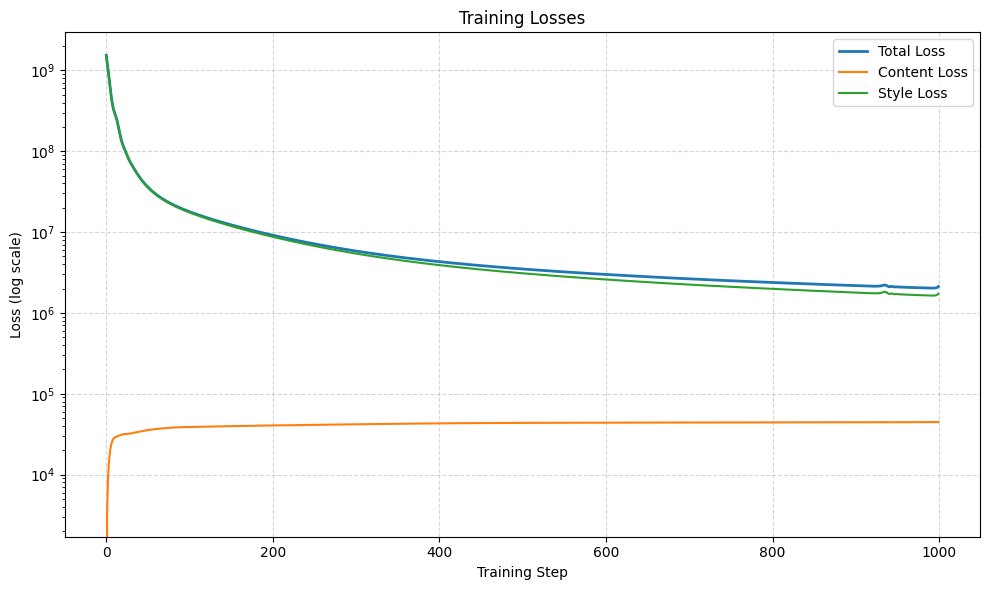

In [5]:
plot_training_curves(baseline_history)

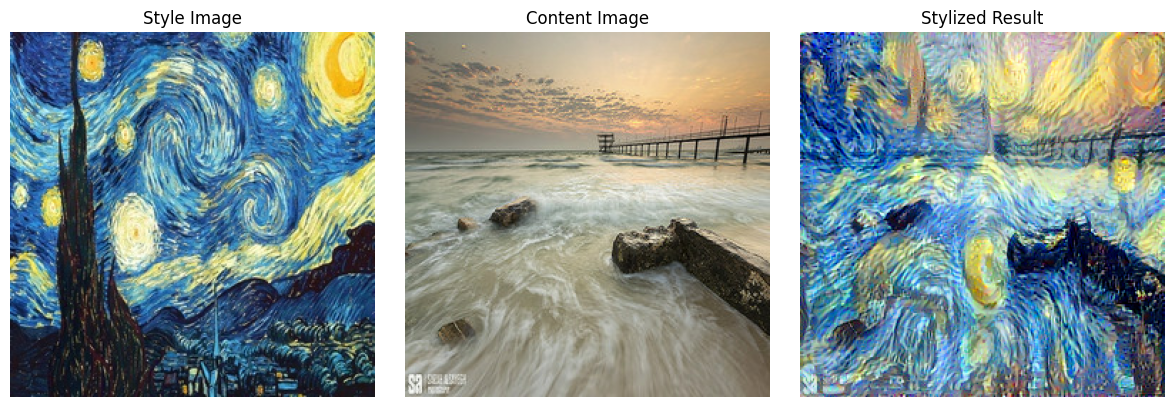

In [6]:
baseline_output = tf.squeeze(BASELINE_MODEL.call(), axis=0).numpy()
show_style_transfer_triplet(
    style_image.numpy(), content_image.numpy(), baseline_output
)


In [7]:
experiment_configs = [
    ExperimentConfig("A", content_weight=1e4, style_weight=1e0),
    ExperimentConfig("B", content_weight=1e0, style_weight=1e4),
    ExperimentConfig("C", content_weight=1e1, style_weight=1e1),
    ExperimentConfig("D", content_weight=1e1, style_weight=1e1, lr=10),
    ExperimentConfig("E", content_weight=1e-5, style_weight=1e1),
    ExperimentConfig("F", content_weight=1e1, style_weight=1e-5),
    ExperimentConfig("G", content_weight=1e0, style_weight=1e2),
]

experiments = run_experiments(
    style_image, content_image, experiment_configs, verbose_every=200
)



--- Starting Config A: alpha=10000.0, beta=1.0, gamma=10.0 ---
Step 0: Total Loss 1677872.62
Step 200: Total Loss 855609.88
Step 400: Total Loss 712932.62
Step 600: Total Loss 648662.56
Step 800: Total Loss 612913.06
Step 1000: Total Loss 587122.94
Step 1200: Total Loss 569912.50
Step 1400: Total Loss 569699.38
Step 1600: Total Loss 549158.31
Step 1800: Total Loss 548846.12
Step 1999: Total Loss 547045.19

--- Starting Config B: alpha=1.0, beta=10000.0, gamma=10.0 ---
Step 0: Total Loss 15371915264.00
Step 200: Total Loss 87429680.00
Step 400: Total Loss 39358240.00
Step 600: Total Loss 26246968.00
Step 800: Total Loss 20140830.00
Step 1000: Total Loss 16548418.00
Step 1200: Total Loss 14107271.00
Step 1400: Total Loss 12383539.00
Step 1600: Total Loss 11249942.00
Step 1800: Total Loss 10173354.00
Step 1999: Total Loss 9578684.00

--- Starting Config C: alpha=10.0, beta=10.0, gamma=10.0 ---
Step 0: Total Loss 15512470.00
Step 200: Total Loss 368275.94
Step 400: Total Loss 275951.50
St

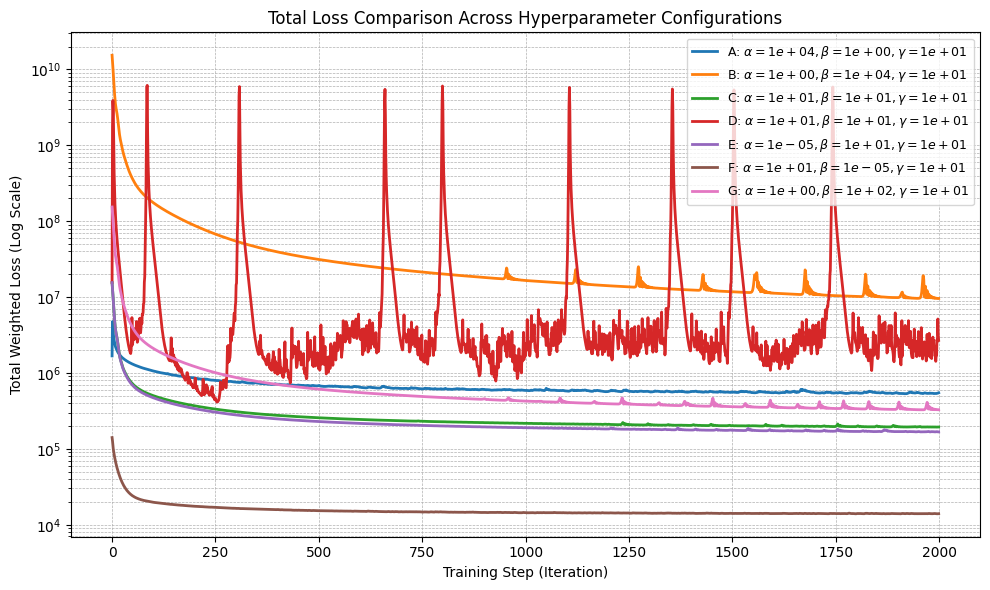

In [8]:
plot_loss_mosaic(experiments)

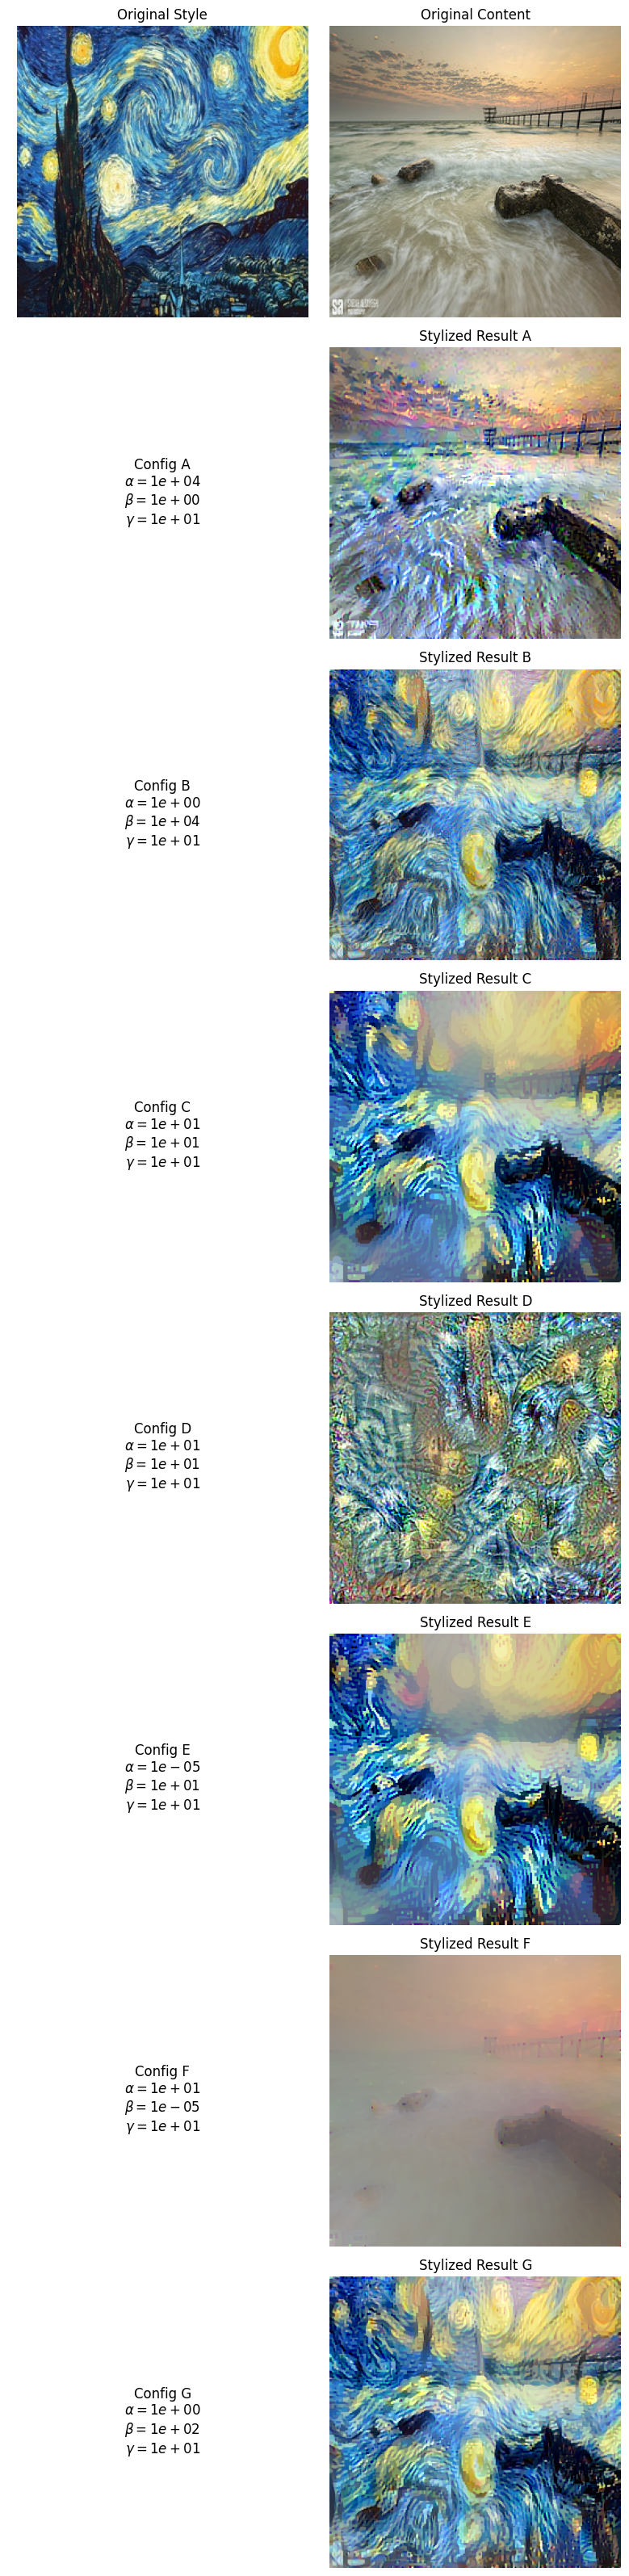

In [9]:
plot_image_mosaic(
    experiments, style_image.numpy(), content_image.numpy()
)
